=== Tabla completa ===
                              accuracy  precision    recall        f1  \
LogisticRegression_NoBalance  0.800933   0.617631  0.262960  0.368819   
LogisticRegression_Over       0.725433   0.421151  0.643761  0.509164   
DecisionTree_NoBalance        0.818533   0.670246  0.353828  0.463131   
DecisionTree_Over             0.759667   0.466635  0.583333  0.517939   
RandomForest_NoBalance        0.807833   0.616044  0.348403  0.445062   
RandomForest_Over             0.802000   0.572746  0.413351  0.480093   
SVM_NoBalance                 0.816467   0.655385  0.359855  0.464391   
SVM_Over                      0.773933   0.491030  0.597498  0.539021   
KNN_NoBalance                 0.793867   0.557050  0.333032  0.416752   
KNN_Over                      0.668567   0.352749  0.596896  0.443435   

                               roc_auc  
LogisticRegression_NoBalance  0.742548  
LogisticRegression_Over       0.743818  
DecisionTree_NoBalance        0.752900  
DecisionT

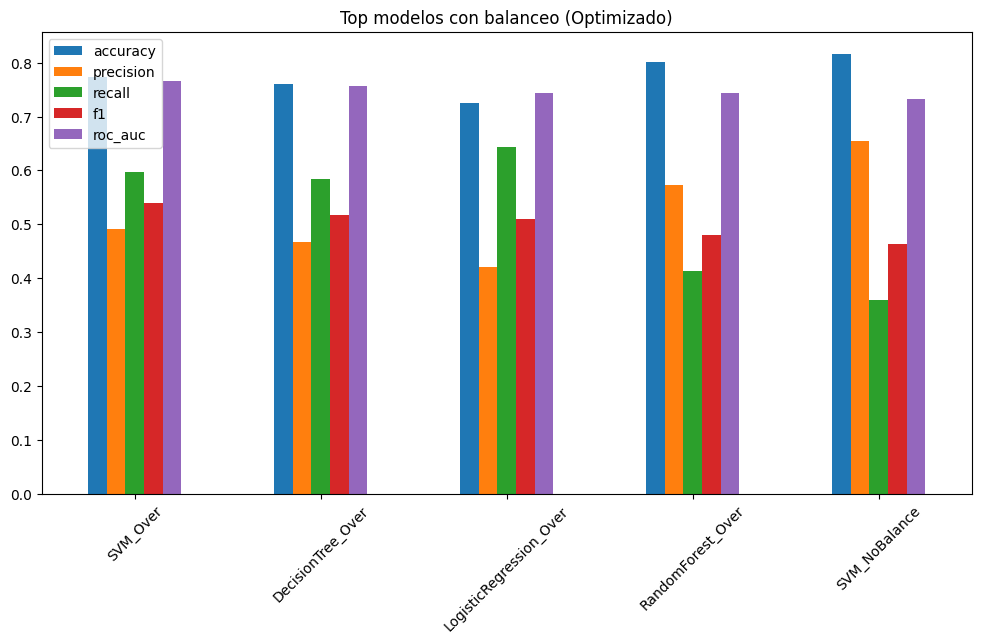

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Pipeline con balanceo
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import RandomOverSampler

# =============================================================
# 1. Cargar conjunto de datos
# =============================================================
df = pd.read_csv("../data/processed/04_default_credit_features.csv")
df = df.drop(columns=["ID"])

TARGET = "default payment next month"
X = df.drop(columns=[TARGET])
y = df[TARGET]

# Columnas
cat_cols = X.select_dtypes(include=["object", "category", "string"]).columns.tolist()
num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

# =============================================================
# 2. Preprocesamiento
# =============================================================
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preproc = ColumnTransformer([
    ("num", numeric_pipeline, num_cols),
    ("cat", categorical_pipeline, cat_cols)
])

# =============================================================
# 3. Modelos optimizados
# =============================================================
modelos = {
    "LogisticRegression": LogisticRegression(max_iter=2000),
    "DecisionTree": DecisionTreeClassifier(max_depth=5),
    "RandomForest": RandomForestClassifier(n_estimators=20, n_jobs=-1), 
    "SVM": SVC(probability=True),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

# =============================================================
# 4. Balanceo optimizado (solo RandomOver)
# =============================================================
estrategias = {
    "NoBalance": None,
    "Over": RandomOverSampler(random_state=42)
}

# =============================================================
# 5. Validación
# =============================================================
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
metricas = ["accuracy", "precision", "recall", "f1", "roc_auc"]
resultados = {}

# =============================================================
# 6. Entrenamiento
# =============================================================
for nombre_modelo, modelo in modelos.items():
    for nombre_estrategia, sampler in estrategias.items():

        steps = [("preprocessing", preproc)]

        if sampler is not None:
            steps.append(("sampling", sampler))

        steps.append(("clf", modelo))

        pipe = Pipeline(steps)

        puntuaciones = cross_validate(
            pipe, X, y, cv=cv, scoring=metricas, n_jobs=-1
        )

        resultados[f"{nombre_modelo}_{nombre_estrategia}"] = {
            m: puntuaciones[f"test_{m}"].mean() for m in metricas
        }

# =============================================================
# 7. Resultados
# =============================================================
tabla = pd.DataFrame(resultados).T
print("=== Tabla completa ===")
print(tabla)

ranking = tabla.sort_values(by="f1", ascending=False)
print("\n=== Ranking ===")
print(ranking)

top_modelos = ranking.head(3)
print("\n=== Top 3 ===")
print(top_modelos)

# =============================================================
# 8. Gráfico
# =============================================================
top5 = ranking.head(5)
top5.plot(kind="bar", figsize=(12,6))
plt.title("Top modelos con balanceo (Optimizado)")
plt.xticks(rotation=45)
plt.show()


=== Ejecutando modelos adicionales ===

=== Tabla completa actualizada ===


,accuracy,precision,recall,f1,roc_auc
LogisticRegression_NoBalance,0.800933,0.617631,0.262960,0.368819,0.742548
LogisticRegression_Over,0.725433,0.421151,0.643761,0.509164,0.743818
DecisionTree_NoBalance,0.818533,0.670246,0.353828,0.463131,0.752900
DecisionTree_Over,0.759667,0.466635,0.583333,0.517939,0.756360
RandomForest_NoBalance,0.807833,0.616044,0.348403,0.445062,0.745000
RandomForest_Over,0.802000,0.572746,0.413351,0.480093,0.744023
SVM_NoBalance,0.816467,0.655385,0.359855,0.464391,0.731805
SVM_Over,0.773933,0.491030,0.597498,0.539021,0.765311
KNN_NoBalance,0.793867,0.557050,0.333032,0.416752,0.703686
KNN_Over,0.668567,0.352749,0.596896,0.443435,0.683802



=== Ranking actualizado ===


,accuracy,precision,recall,f1,roc_auc
SVM_Over,0.773933,0.491030,0.597498,0.539021,0.765311
GradientBoosting_Over,0.762700,0.472420,0.622664,0.537228,0.780318
AdaBoost_Over,0.766300,0.477477,0.595690,0.530030,0.770839
DecisionTree_Over,0.759667,0.466635,0.583333,0.517939,0.756360
LogisticRegression_Over,0.725433,0.421151,0.643761,0.509164,0.743818
RandomForest_Over,0.802000,0.572746,0.413351,0.480093,0.744023
GradientBoosting_NoBalance,0.820933,0.671683,0.372514,0.479214,0.782327
SVM_NoBalance,0.816467,0.655385,0.359855,0.464391,0.731805
DecisionTree_NoBalance,0.818533,0.670246,0.353828,0.463131,0.752900
RandomForest_NoBalance,0.807833,0.616044,0.348403,0.445062,0.745000



=== Top 3 modelos ===


,accuracy,precision,recall,f1,roc_auc
SVM_Over,0.773933,0.491030,0.597498,0.539021,0.765311
GradientBoosting_Over,0.762700,0.472420,0.622664,0.537228,0.780318
AdaBoost_Over,0.766300,0.477477,0.595690,0.530030,0.770839


<Figure size 1400x600 with 0 Axes>

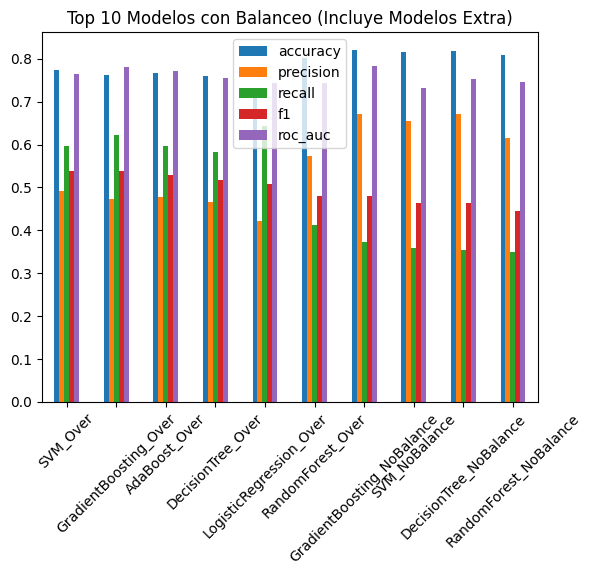

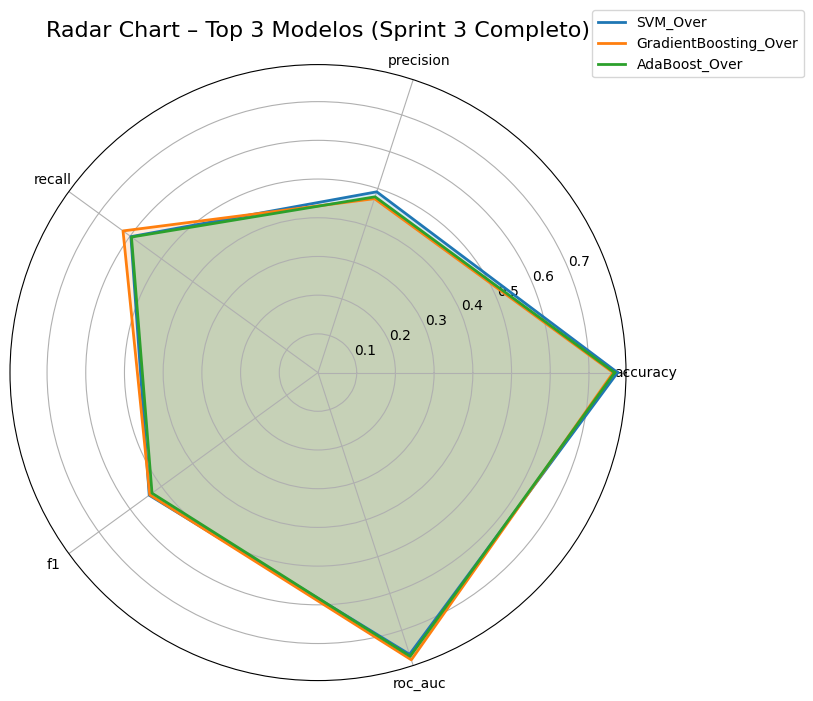

In [3]:
# =============================================================
# Modelos adicionales (Sprint 3 extendido)
# =============================================================
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier

modelos_extra = {
    "GradientBoosting": GradientBoostingClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "ExtraTrees": ExtraTreesClassifier(n_estimators=50, n_jobs=-1)
}

print("\n=== Ejecutando modelos adicionales ===")

for nombre_modelo, modelo in modelos_extra.items():
    for nombre_estrategia, sampler in estrategias.items():

        steps = [("preprocessing", preproc)]

        if sampler is not None:
            steps.append(("sampling", sampler))

        steps.append(("clf", modelo))

        pipe = Pipeline(steps)

        puntuaciones = cross_validate(
            pipe, X, y, cv=cv, scoring=metricas, n_jobs=-1
        )

        resultados[f"{nombre_modelo}_{nombre_estrategia}"] = {
            m: puntuaciones[f"test_{m}"].mean() for m in metricas
        }

# =============================================================
# Tabla actualizada con TODOS los modelos
# =============================================================
tabla = pd.DataFrame(resultados).T
print("\n=== Tabla completa actualizada ===")
display(tabla)

ranking = tabla.sort_values(by="f1", ascending=False)
print("\n=== Ranking actualizado ===")
display(ranking)

top3 = ranking.head(3)
print("\n=== Top 3 modelos ===")
display(top3)

# =============================================================
# Visualización de barras con TODOS los modelos
# =============================================================
plt.figure(figsize=(14,6))
ranking.head(10).plot(kind="bar")
plt.title("Top 10 Modelos con Balanceo (Incluye Modelos Extra)")
plt.xticks(rotation=45)
plt.show()

# =============================================================
# Radar Chart del Top 3
# =============================================================
import numpy as np
import matplotlib.pyplot as plt

def radar_chart(df, title):
    categorias = df.columns.tolist()
    N = len(categorias)

    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

    for idx, row in df.iterrows():
        valores = row.values.flatten().tolist()
        valores += valores[:1]
        ax.plot(angles, valores, linewidth=2, label=idx)
        ax.fill(angles, valores, alpha=0.15)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categorias)
    ax.set_title(title, size=16, pad=20)
    ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
    plt.show()

metricas_radar = ["accuracy", "precision", "recall", "f1", "roc_auc"]
radar_chart(top3[metricas_radar], "Radar Chart – Top 3 Modelos (Sprint 3 Completo)")